# 作业 2




## 2 多层感知机

### 2.1 理论计算题

#### 1. 非线性激活函数的重要性

设输入为 $x$，单隐层 MLP 的隐藏层没有非线性激活函数，则

$$h=W_1x+b_1$$

输出层为

$$o=W_2h+b_2$$

代入隐藏层表达式：

$$o=W_2(W_1x+b_1)+b_2=(W_2W_1)x+(W_2b_1+b_2)$$

令

$$W'=W_2W_1,\qquad b'=W_2b_1+b_2$$

则

$$o=W'x+b'$$

这说明该网络等价于一个单层线性神经网络。也就是说，多层线性变换的复合仍然是线性变换；如果没有非线性激活函数，增加隐藏层不会提升模型表达非线性关系的能力。

#### 2. Sigmoid 与 tanh 的表达式和导数

Sigmoid 函数：

$$\operatorname{Sigmoid}(x)=\sigma(x)=\frac{1}{1+e^{-x}}$$

其导数为

$$\sigma'(x)=\frac{e^{-x}}{(1+e^{-x})^2}$$

又因为

$$\sigma(x)=\frac{1}{1+e^{-x}},\qquad 1-\sigma(x)=\frac{e^{-x}}{1+e^{-x}}$$

所以

$$\sigma'(x)=\sigma(x)(1-\sigma(x))$$

tanh 函数：

$$\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}$$

其导数为

$$\tanh'(x)=1-\tanh^2(x)$$

因此二者导数与自身函数值的关系为

$$\operatorname{Sigmoid}'(x)=\operatorname{Sigmoid}(x)(1-\operatorname{Sigmoid}(x))$$

$$\tanh'(x)=1-\tanh^2(x)$$


### 2.2 编程题：从零实现单隐藏层 MLP

In [15]:
import random
import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=4, suppress=True)

print('numpy version:', np.__version__)

numpy version: 1.26.4


In [16]:
# 使用 Fashion-MNIST。这里不依赖深度学习框架，直接读取原始 IDX 文件。
FASHION_URLS = {
    'train_images': 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz',
    'train_labels': 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz',
    'test_images': 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz',
    'test_labels': 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz',
}

def download_file(url, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return path

def read_idx_images(path):
    with gzip.open(path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows * cols).astype(np.float32) / 255.0

def read_idx_labels(path):
    with gzip.open(path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)

try:
    data_dir = Path('data/fashion-mnist/raw')
    files = {k: download_file(v, data_dir / Path(v).name) for k, v in FASHION_URLS.items()}
    X_train_all = read_idx_images(files['train_images'])
    y_train_all = read_idx_labels(files['train_labels'])
    X_test_all = read_idx_images(files['test_images'])
    y_test_all = read_idx_labels(files['test_labels'])
    dataset_name = 'Fashion-MNIST'
except Exception as e:
    # 若当前环境无法联网，使用 sklearn digits 保证代码仍可运行；提交时主路径仍为 Fashion-MNIST。
    from sklearn.datasets import load_digits
    digits = load_digits()
    X = (digits.data / 16.0).astype(np.float32)
    y = digits.target.astype(np.int64)
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(X))
    split = int(0.8 * len(X))
    X_train_all, y_train_all = X[perm[:split]], y[perm[:split]]
    X_test_all, y_test_all = X[perm[split:]], y[perm[split:]]
    dataset_name = f'sklearn digits fallback because Fashion-MNIST download failed: {e}'

rng = np.random.default_rng(SEED)
train_size = min(6000, len(X_train_all))
test_size = min(1000, len(X_test_all))
train_idx = rng.choice(len(X_train_all), size=train_size, replace=False)
test_idx = rng.choice(len(X_test_all), size=test_size, replace=False)
X_train, y_train = X_train_all[train_idx], y_train_all[train_idx]
X_test, y_test = X_test_all[test_idx], y_test_all[test_idx]
num_classes = int(max(y_train.max(), y_test.max()) + 1)

print('dataset:', dataset_name)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)
print('classes:', num_classes, 'pixel range:', X_train.min(), X_train.max())

dataset: Fashion-MNIST
X_train: (6000, 784) y_train: (6000,)
X_test : (1000, 784) y_test : (1000,)
classes: 10 pixel range: 0.0 1.0


In [17]:
def relu(X):
    return np.maximum(0, X)

def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)

def cross_entropy(probs, y):
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()

def accuracy(probs, y):
    return (probs.argmax(axis=1) == y).mean()

def init_params(input_dim=None, hidden_dim=256, output_dim=None, seed=SEED):
    input_dim = X_train.shape[1] if input_dim is None else input_dim
    output_dim = num_classes if output_dim is None else output_dim
    rng = np.random.default_rng(seed)
    return {
        'W1': rng.normal(0, 0.01, size=(input_dim, hidden_dim)).astype(np.float32),
        'b1': np.zeros(hidden_dim, dtype=np.float32),
        'W2': rng.normal(0, 0.01, size=(hidden_dim, output_dim)).astype(np.float32),
        'b2': np.zeros(output_dim, dtype=np.float32),
    }

def forward(X, params, training=False, dropout=0.0):
    H_pre = X @ params['W1'] + params['b1']
    H = relu(H_pre)
    mask = None
    if training and dropout > 0:
        keep_prob = 1 - dropout
        mask = (np.random.rand(*H.shape) < keep_prob).astype(np.float32) / keep_prob
        H *= mask
    logits = H @ params['W2'] + params['b2']
    probs = softmax(logits)
    return probs, (X, H_pre, H, mask)

def train_mlp(X_train, y_train, X_test, y_test, *, epochs=8, batch_size=128, lr=0.2, weight_decay=0.0, dropout=0.0, seed=SEED):
    rng = np.random.default_rng(seed)
    params = init_params(seed=seed)
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    n = len(X_train)
    for epoch in range(1, epochs + 1):
        for start in range(0, n, batch_size):
            batch = rng.permutation(n)[start:start + batch_size] if start == 0 else indices[start:start + batch_size]
            if start == 0:
                indices = rng.permutation(n)
                batch = indices[start:start + batch_size]
            Xb, yb = X_train[batch], y_train[batch]
            probs, (X, H_pre, H, mask) = forward(Xb, params, training=True, dropout=dropout)
            m = len(yb)
            dlogits = probs.copy()
            dlogits[np.arange(m), yb] -= 1
            dlogits /= m
            dW2 = H.T @ dlogits
            db2 = dlogits.sum(axis=0)
            dH = dlogits @ params['W2'].T
            if mask is not None:
                dH *= mask
            dH_pre = dH * (H_pre > 0)
            dW1 = X.T @ dH_pre
            db1 = dH_pre.sum(axis=0)
            if weight_decay > 0:
                params['W1'] *= (1 - lr * weight_decay)
                params['W2'] *= (1 - lr * weight_decay)
            params['W1'] -= lr * dW1
            params['b1'] -= lr * db1
            params['W2'] -= lr * dW2
            params['b2'] -= lr * db2
        train_probs, _ = forward(X_train, params)
        test_probs, _ = forward(X_test, params)
        history['train_loss'].append(cross_entropy(train_probs, y_train))
        history['test_loss'].append(cross_entropy(test_probs, y_test))
        history['train_acc'].append(accuracy(train_probs, y_train))
        history['test_acc'].append(accuracy(test_probs, y_test))
        print(f"epoch {epoch:02d}: train loss={history['train_loss'][-1]:.4f}, test loss={history['test_loss'][-1]:.4f}, train acc={history['train_acc'][-1]:.3f}, test acc={history['test_acc'][-1]:.3f}")
    return params, history

params_base, hist_base = train_mlp(X_train, y_train, X_test, y_test, epochs=8, lr=0.2)

epoch 01: train loss=1.0654, test loss=1.0612, train acc=0.566, test acc=0.582
epoch 02: train loss=0.7620, test loss=0.7743, train acc=0.691, test acc=0.694
epoch 03: train loss=0.8502, test loss=0.8954, train acc=0.705, test acc=0.677
epoch 04: train loss=0.5912, test loss=0.6250, train acc=0.787, test acc=0.777
epoch 05: train loss=0.6227, test loss=0.6785, train acc=0.771, test acc=0.746
epoch 06: train loss=0.5351, test loss=0.5866, train acc=0.808, test acc=0.784
epoch 07: train loss=0.5223, test loss=0.5747, train acc=0.818, test acc=0.789
epoch 08: train loss=0.5125, test loss=0.5624, train acc=0.813, test acc=0.798


## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

#### 1. 过拟合与欠拟合

训练误差是在训练集上计算的误差，反映模型对已见样本的拟合程度。泛化误差是在未见样本或测试分布上的误差，反映模型对新数据的预测能力。

当训练误差极低但泛化误差很高时，模型通常处于**过拟合**状态：模型不仅学习了真实规律，也记住了训练集中的噪声和偶然模式。缓解方法包括降低模型复杂度、加入 $L_2$ 权重衰减、使用 Dropout、早停、数据增强、增加训练数据，以及用交叉验证选择合适超参数。

当训练误差和泛化误差都很高时，模型通常处于**欠拟合**状态，说明模型表达能力不足、训练不充分或优化效果较差。

#### 2. K 折交叉验证

K 折交叉验证步骤：

1. 将训练数据随机划分为 $K$ 个互不重叠、大小尽量相同的子集；
2. 每次取其中 1 折作为验证集，其余 $K-1$ 折作为训练集；
3. 重复 $K$ 次，使每一折都恰好作为一次验证集；
4. 记录每次验证误差并取平均，作为该模型或超参数组合的泛化误差估计；
5. 比较不同模型或超参数的平均验证误差，选择效果最好的方案；
6. 最后使用选出的超参数在完整训练集上重新训练。

K 折交叉验证比单次训练/验证划分更稳定，特别适合样本量较小时评估模型泛化能力。


### 3.2 编程题：加入 L2 正则化和 Dropout

In [18]:
def dropout_layer(X, dropout, is_training=True):
    assert 0 <= dropout <= 1
    if (not is_training) or dropout == 0:
        return X
    if dropout == 1:
        return np.zeros_like(X)
    keep_prob = 1 - dropout
    mask = (np.random.rand(*X.shape) < keep_prob).astype(np.float32)
    return mask * X / keep_prob

sample = np.arange(12, dtype=np.float32).reshape(3, 4)
print('输入:\n', sample)
print('训练阶段 dropout=0.5:\n', dropout_layer(sample, 0.5, is_training=True))
print('测试阶段 dropout=0.5:\n', dropout_layer(sample, 0.5, is_training=False))

输入:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]
训练阶段 dropout=0.5:
 [[ 0.  0.  0.  0.]
 [ 8. 10. 12.  0.]
 [ 0.  0. 20.  0.]]
测试阶段 dropout=0.5:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]



================== No regularization ==================
epoch 01: train loss=1.0014, test loss=1.0001, train acc=0.637, test acc=0.625
epoch 02: train loss=0.7728, test loss=0.8090, train acc=0.739, test acc=0.704
epoch 03: train loss=0.6666, test loss=0.6985, train acc=0.749, test acc=0.724
epoch 04: train loss=0.5917, test loss=0.6291, train acc=0.780, test acc=0.772
epoch 05: train loss=0.5628, test loss=0.6192, train acc=0.797, test acc=0.773
epoch 06: train loss=0.5193, test loss=0.5612, train acc=0.809, test acc=0.789
epoch 07: train loss=0.5488, test loss=0.6077, train acc=0.798, test acc=0.763
epoch 08: train loss=0.4684, test loss=0.5199, train acc=0.844, test acc=0.821

================== L2 weight decay ==================
epoch 01: train loss=1.0034, test loss=1.0020, train acc=0.637, test acc=0.625
epoch 02: train loss=0.7771, test loss=0.8130, train acc=0.738, test acc=0.705
epoch 03: train loss=0.6707, test loss=0.7017, train acc=0.748, test acc=0.722
epoch 04: train los

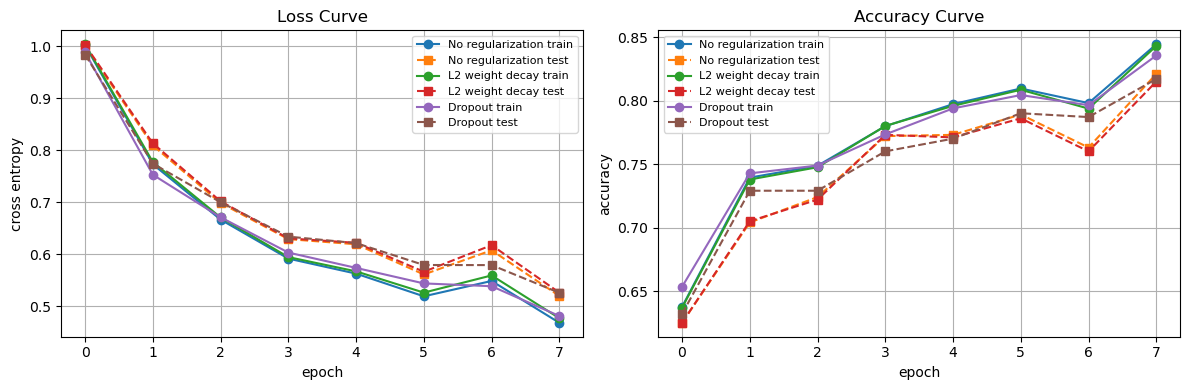

No regularization  final test loss=0.5199, test acc=0.821
L2 weight decay    final test loss=0.5263, test acc=0.815
Dropout            final test loss=0.5260, test acc=0.817


In [19]:
experiments = {
    'No regularization': {'weight_decay': 0.0, 'dropout': 0.0, 'seed': 10},
    'L2 weight decay': {'weight_decay': 1e-3, 'dropout': 0.0, 'seed': 10},
    'Dropout': {'weight_decay': 0.0, 'dropout': 0.5, 'seed': 10},
}

histories = {}
for name, cfg in experiments.items():
    print('\n' + '=' * 18, name, '=' * 18)
    _, histories[name] = train_mlp(X_train, y_train, X_test, y_test, epochs=8, lr=0.2, batch_size=128, weight_decay=cfg['weight_decay'], dropout=cfg['dropout'], seed=cfg['seed'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in histories.items():
    axes[0].plot(hist['train_loss'], marker='o', label=f'{name} train')
    axes[0].plot(hist['test_loss'], marker='s', linestyle='--', label=f'{name} test')
    axes[1].plot(hist['train_acc'], marker='o', label=f'{name} train')
    axes[1].plot(hist['test_acc'], marker='s', linestyle='--', label=f'{name} test')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('cross entropy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for name, hist in histories.items():
    print(f"{name:18s} final test loss={hist['test_loss'][-1]:.4f}, test acc={hist['test_acc'][-1]:.3f}")

## 4 数值稳定性和激活函数

### 4.1 理论计算题

深层网络的反向传播梯度包含多层矩阵连乘：

$$\prod_{i=t}^{d-1}\frac{\partial h^{i+1}}{\partial h^i}$$

#### 1. 梯度消失与梯度爆炸

设每层局部梯度或权重矩阵的典型尺度为 $c_i$，则梯度范数大致随 $\prod_i c_i$ 变化。当多数 $c_i<1$ 时，连乘会随层数指数级变小，靠近输入层的梯度接近 0，即梯度消失；当多数 $c_i>1$ 时，连乘会指数级变大，导致梯度爆炸甚至数值溢出。

从激活函数导数看，Sigmoid 的导数为

$$\sigma'(x)=\sigma(x)(1-\sigma(x))\le 0.25$$

当输入绝对值较大时，Sigmoid 饱和，导数接近 0，深层连乘后梯度会迅速衰减。从矩阵角度看，如果权重矩阵的奇异值普遍小于 1，梯度范数逐层缩小；如果奇异值普遍大于 1，梯度范数逐层放大。

#### 2. ReLU 缓解梯度消失的原因

ReLU 定义为

$$\operatorname{ReLU}(x)=\max(0,x)$$

导数为

$$
\operatorname{ReLU}'(x)=
\begin{cases}
1, & x>0\\
0, & x\le 0
\end{cases}
$$

在正激活区域，ReLU 的导数为 1，不会像 Sigmoid 或 tanh 那样因为饱和而接近 0，所以梯度可以更直接地传播到前层。不过 ReLU 仍需要合理初始化和学习率，否则仍可能发生梯度爆炸或死亡 ReLU。


### 4.2 编程题：深层网络中的梯度消失/爆炸与修复


Sigmoid + Normal(std=1)
finite: True
first 5 layer grad norms: ['4.20e-01', '2.70e-01', '2.04e-01', '1.66e-01', '1.24e-01']
last  5 layer grad norms: ['2.55e-02', '2.97e-02', '3.09e-02', '3.15e-02', '3.51e-02']

ReLU + Normal(std=10)
finite: True
first 5 layer grad norms: ['2.62e+38', '5.16e+38', '6.44e+38', '7.99e+38', '9.71e+38']
last  5 layer grad norms: ['1.12e+39', '9.86e+38', '1.03e+39', '9.07e+38', '6.91e+38']

ReLU + Xavier uniform
finite: True
first 5 layer grad norms: ['3.00e-04', '7.09e-04', '9.72e-04', '1.31e-03', '1.39e-03']
last  5 layer grad norms: ['1.35e-03', '1.34e-03', '1.27e-03', '1.17e-03', '9.08e-04']


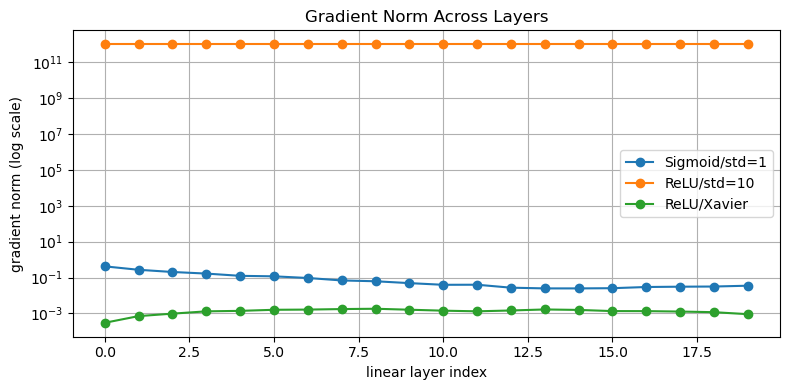

In [20]:
# 实验目的与题目一致：观察 Sigmoid 梯度消失、ReLU 大初始化梯度爆炸，以及 Xavier 初始化后的稳定性。

def sigmoid_np(z):
    return 1 / (1 + np.exp(-np.clip(z, -60, 60)))

def init_weight(fan_in, fan_out, init, rng):
    if init == 'normal1':
        return rng.normal(0, 1, size=(fan_in, fan_out)).astype(np.float64)
    if init == 'normal10':
        return rng.normal(0, 10, size=(fan_in, fan_out)).astype(np.float64)
    if init == 'xavier':
        limit = np.sqrt(6 / (fan_in + fan_out))
        return rng.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float64)
    raise ValueError(init)

def numpy_gradient_report(activation='sigmoid', init='normal1', name=''):
    rng = np.random.default_rng(SEED)
    depth, width, batch = 20, 256, 128
    Ws = [init_weight(width, width, init, rng) for _ in range(depth)]
    X = rng.normal(0, 1, size=(batch, width))
    activations, preacts = [X], []
    H = X
    
    for W in Ws:
        Z = H @ W
        preacts.append(Z)
        if activation == 'sigmoid':
            H = sigmoid_np(Z)
        elif activation == 'relu':
            H = np.maximum(0, Z)
        else:
            raise ValueError(activation)
        H = np.nan_to_num(H, nan=0.0, posinf=1e100, neginf=-1e100)
        H = np.clip(H, -1e100, 1e100)
        activations.append(H)
    
    # 用 mean(H) 作为简单标量目标，手写链式法则反传。
    dH = np.ones_like(H) / H.size
    norms = []
    for i in range(depth - 1, -1, -1):
        Z = preacts[i]
        if activation == 'sigmoid':
            S = sigmoid_np(Z)
            dZ = dH * S * (1 - S)
        else:
            dZ = dH * (Z > 0)
        dW = activations[i].T @ dZ
        norm = np.linalg.norm(np.nan_to_num(dW, nan=np.inf, posinf=np.inf, neginf=-np.inf))
        norms.append(norm)
        dH = dZ @ Ws[i].T
        dH = np.nan_to_num(dH, nan=np.inf, posinf=np.inf, neginf=-np.inf)
    norms = norms[::-1]
    finite = np.all(np.isfinite(norms))
    print(f'\n{name}')
    print('finite:', finite)
    print('first 5 layer grad norms:', [f'{v:.2e}' for v in norms[:5]])
    print('last  5 layer grad norms:', [f'{v:.2e}' for v in norms[-5:]])
    return norms

sigmoid_norms = numpy_gradient_report('sigmoid', 'normal1', 'Sigmoid + Normal(std=1)')
relu_big_norms = numpy_gradient_report('relu', 'normal10', 'ReLU + Normal(std=10)')
xavier_norms = numpy_gradient_report('relu', 'xavier', 'ReLU + Xavier uniform')

plt.figure(figsize=(8, 4))
for label, norms in [('Sigmoid/std=1', sigmoid_norms), ('ReLU/std=10', relu_big_norms), ('ReLU/Xavier', xavier_norms)]:
    clipped = np.clip(np.array(norms, dtype=float), 1e-12, 1e12)
    plt.plot(clipped, marker='o', label=label)
plt.yscale('log')
plt.xlabel('linear layer index')
plt.ylabel('gradient norm (log scale)')
plt.title('Gradient Norm Across Layers')
plt.legend()
plt.tight_layout()
plt.show()

## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

#### 1. 协变量偏移（Covariate Shift）

协变量偏移表示训练分布和测试分布的输入边缘分布不同：

$$p(x)\ne q(x)$$

但条件分布保持不变：

$$p(y|x)=q(y|x)$$

例如医疗影像中，训练数据来自 A 医院，测试数据来自 B 医院。两家医院设备型号、成像协议和患者年龄结构不同，图像输入 $x$ 的分布会改变；但给定同样的病灶影像特征后，疾病标签 $y$ 的判定规律基本相同。因此这是协变量偏移。

语音识别也类似：训练语音多来自安静环境，部署时来自嘈杂街道。噪声改变了输入语音特征分布 $p(x)$，但同一语音内容对应的文字标签机制 $p(y|x)$ 没有本质改变。

#### 2. 标签偏移（Label Shift）

标签偏移表示标签边缘分布不同：

$$p(y)\ne q(y)$$

但类别条件分布保持不变：

$$p(x|y)=q(x|y)$$

例如电商图像分类器训练时各类商品较均衡，但促销季测试数据中“服装”类别占比显著增加。每个类别内部图像分布 $p(x|y)$ 近似不变，但类别先验 $p(y)$ 改变了。

二者联系是训练环境与测试环境都存在分布不一致，都会影响泛化性能；区别是协变量偏移主要改变输入分布 $p(x)$，标签偏移主要改变标签先验 $p(y)$。


### 5.2 编程题：模拟协变量偏移并用权重校正

训练集 P: x ~ N(-1, 1), 样本数 = 1000
测试集 Q: x ~ N( 2, 1), 样本数 = 500
domain classifier accuracy: 0.9346666666666666
baseline test MSE: 83.0334
weighted  test MSE: 9.2263
baseline coef/intercept: 0.3146 -0.1451
weighted  coef/intercept: 3.1431 -0.0843


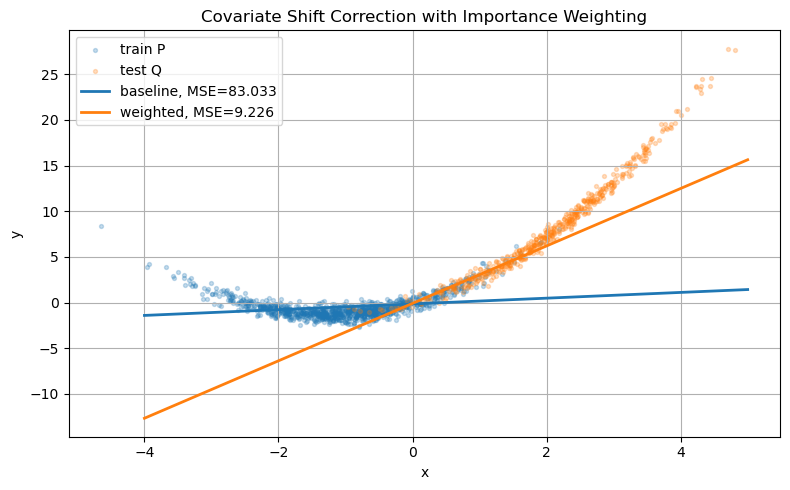

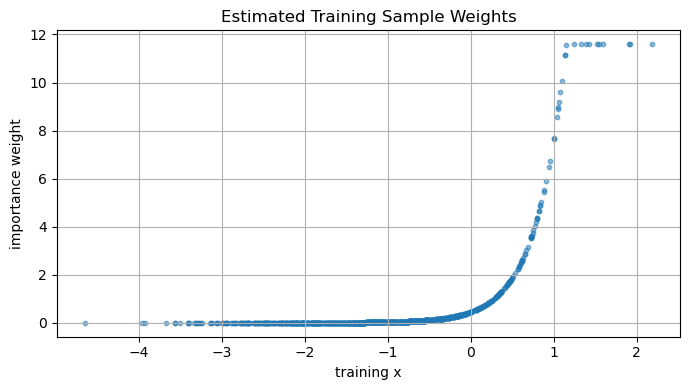

In [21]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(SEED)
n_train, n_test = 1000, 500
x_train = rng.normal(-1, 1, size=(n_train, 1))
x_test = rng.normal(2, 1, size=(n_test, 1))
noise_train = rng.normal(0, 0.5, size=n_train)
noise_test = rng.normal(0, 0.5, size=n_test)

y_train = 2 * x_train[:, 0] + 0.8 * (x_train[:, 0] ** 2) + noise_train
y_test = 2 * x_test[:, 0] + 0.8 * (x_test[:, 0] ** 2) + noise_test

base_model = LinearRegression()
base_model.fit(x_train, y_train)
base_pred = base_model.predict(x_test)
base_mse = mean_squared_error(y_test, base_pred)

X_domain = np.vstack([x_train, x_test])
y_domain = np.r_[np.zeros(n_train), np.ones(n_test)]
clf = LogisticRegression(max_iter=1000)
clf.fit(X_domain, y_domain)
prob_test = clf.predict_proba(x_train)[:, 1]
prob_train = 1 - prob_test
weights = prob_test / np.clip(prob_train, 1e-6, None)
weights = weights / weights.mean()
weights = np.clip(weights, 0, np.quantile(weights, 0.99))

weighted_model = LinearRegression()
weighted_model.fit(x_train, y_train, sample_weight=weights)
weighted_pred = weighted_model.predict(x_test)
weighted_mse = mean_squared_error(y_test, weighted_pred)

print('训练集 P: x ~ N(-1, 1), 样本数 =', n_train)
print('测试集 Q: x ~ N( 2, 1), 样本数 =', n_test)
print('domain classifier accuracy:', clf.score(X_domain, y_domain))
print('baseline test MSE:', round(base_mse, 4))
print('weighted  test MSE:', round(weighted_mse, 4))
print('baseline coef/intercept:', round(base_model.coef_[0], 4), round(base_model.intercept_, 4))
print('weighted  coef/intercept:', round(weighted_model.coef_[0], 4), round(weighted_model.intercept_, 4))

xs = np.linspace(-4, 5, 300).reshape(-1, 1)
plt.figure(figsize=(8, 5))
plt.scatter(x_train[:, 0], y_train, s=8, alpha=0.25, label='train P')
plt.scatter(x_test[:, 0], y_test, s=8, alpha=0.25, label='test Q')
plt.plot(xs[:, 0], base_model.predict(xs), label=f'baseline, MSE={base_mse:.3f}', linewidth=2)
plt.plot(xs[:, 0], weighted_model.predict(xs), label=f'weighted, MSE={weighted_mse:.3f}', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Covariate Shift Correction with Importance Weighting')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(x_train[:, 0], weights, s=10, alpha=0.5)
plt.xlabel('training x')
plt.ylabel('importance weight')
plt.title('Estimated Training Sample Weights')
plt.tight_layout()
plt.show()